# PandasAI Quickstart Guide

This notebook demonstrates how to get started with PandasAI and how to use it to analyze data through natural language.

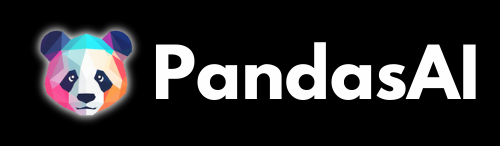


In [1]:
# Importing the required libraries
import pandas as pd
import pandasai as pai
from pandasai_litellm.litellm import LiteLLM
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from IPython.display import Image, display

In [2]:
# Load environment variables
load_dotenv()

True

# 1. Getting Familiar with PandasAI
This section will cover the basics of PandasAI, such as loading data and using the .chat() method to talk to it.

## Read Database Directly
For this example, we will load our data directly from our Postgres database using SQLAlquemy 

In [3]:
# Get values from .env
DB_USER = os.getenv("username")
DB_PASS = os.getenv("password")
DB_HOST = os.getenv("host")
DB_PORT = os.getenv("port")
DB_NAME = os.getenv("database")

In [4]:
# Create connection to Postgres
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require")

In [5]:
# Connect to Postgres
query = "SELECT * FROM users LIMIT 1000;"

# Load data into pandas
database_df = pd.read_sql(query, engine)
print("Data loaded from Postgres")

database_df.head()

Data loaded from Postgres


,user_id,signup_date,country,device_type
0,1,2024-06-02,Rest,iOS
1,2,2024-03-20,India,Android
2,3,2023-09-17,EU,Web
3,4,2024-02-05,India,iOS
4,5,2025-06-08,India,Web


## Set up LLM

Use `pandasai_litellm` to select the LLM of your choice and use PandasAI

In [6]:
# Initialize LiteLLM with an OpenAI model
llm = LiteLLM(model="gpt-4.1-mini")

# Configure PandasAI to use this LLM
pai.config.set({
    "llm": llm
})

## Chat with your data
Now we will use the .chat() method to chat with our data

In [7]:
# Convert our normal pandas dataframe to a pandasai dataframe
database_df = pai.DataFrame(database_df)

In [8]:
# Chat with the dataframe
response = database_df.chat("What is the most popular device type per country?")
print(response)

  country device_type  user_count
0      EU         Web          65
1   India         Web          67
2    Rest         iOS          78
3      US         iOS         142


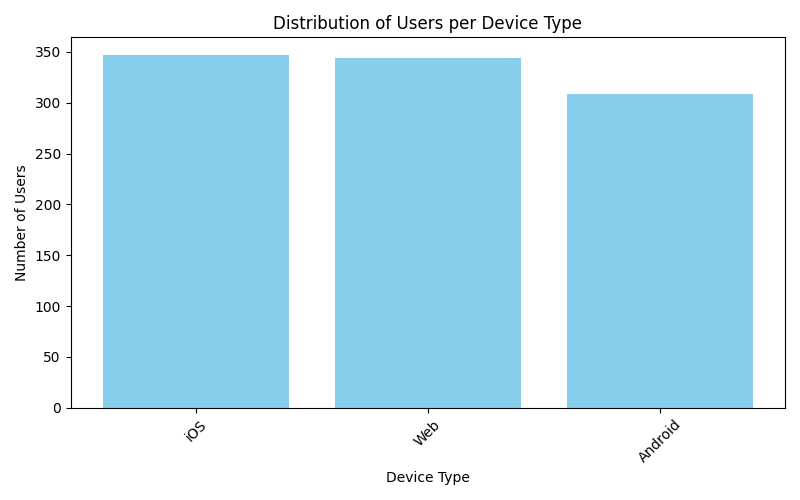

In [9]:
response = database_df.chat("Plot a bar chart showing the distribution of users per device type")

# Extract the path from ChartResponse object
chart_path = response.path if hasattr(response, 'path') else str(response)

# Display the chart with IPython display
display(Image(filename=chart_path))

In [10]:
# Chat with the dataframe
response = database_df.chat("[Ask your question here]")
print(response)

exports/charts/temp_chart_d09d1a94-695a-4036-a340-3f10ea7375e9.png


## Read Database using PandasAI DB Data Extensions

Now we will learn how to load our data from our Postgres database using the .create() method. This will also create a dataset (locally) which can be reloaded in the future.

In [ ]:
# Create a dataset once from the users table which can be reused anytime.
# users_dataset = pai.create(
#     path="public/users",
#     description="Users table from PostgreSQL database",
#     source={
#         "type": "postgres",
#         "connection": {
#             "host": DB_HOST,
#             "port": int(DB_PORT),
#             "user": DB_USER,
#             "password": DB_PASS,
#             "database": DB_NAME
#         },
#         "table": "users"
#     }
# )

# Load the previously created dataset
users_dataset = pai.load("public/users")

In [14]:
# Chat with the dataframe
response = users_dataset.chat("What is the most popular device type per country?")
print(response)

  country device_type  user_count
0      EU         Web        1344
1   India         Web        1354
2    Rest         Web        1348
3      US         iOS        2723


# 2. Using a Semantic Layer in PandasAI
In this section, we will explore how to use a semantic layer in PandasAI in order to improve the accuracy of the AI agent.

## Adding Column Information

In [ ]:
# Create a dataset once from the subscriptions table which can be reused anytime.
# subscriptions_dataset = pai.create(
#     path="public/subscriptions",
#     description="Tracks user subscriptions to different plans",
#     source={
#         "type": "postgres",
#         "connection": {
#             "host": DB_HOST,
#             "port": int(DB_PORT),
#             "user": DB_USER,
#             "password": DB_PASS,
#             "database": DB_NAME
#         },
#         "table": "subscriptions",
#         "columns": [
#             {"name": "subscription_id", "type": "integer", "description": "Unique identifier for the subscription"},
#             {"name": "user_id", "type": "integer", "description": "Foreign key linking to the users table"},
#             {"name": "plan", "type": "string", "description": "The subscription plan (e.g., free, monthly, annual)"},
#             {"name": "start_date", "type": "datetime", "description": "Date when the subscription started"},
#             {"name": "end_date", "type": "datetime", "description": "Date when the subscription ended (if applicable)"},
#             {"name": "status", "type": "string", "description": "Current status of the subscription (e.g., active, canceled, expired)"}
#         ]
#     }
# )

# Load the previously created dataset (with semantic layer column descriptions)
subscriptions_dataset = pai.load("public/subscriptions")

## Enhancing Your Semantic Layer

The semantic layer you just created can be further enhanced with additional features to improve AI accuracy and data understanding:

### What else can you add?

- **Column Expressions**: Define calculated/derived columns using formulas (e.g., `total_revenue = transaction_amount * (1 + tax_rate)`)
- **Column Aliases**: Create alternative names for columns to improve natural language understanding
- **Transformations**: Apply data transformations like anonymization or timezone conversion
- **Group By**: Specify which columns can be used for grouping operations

### How to add them?

These features must be added by **editing the schema.yaml file directly** in `datasets/public/subscriptions/schema.yaml`. 

For example, to add an alias and expression:
```yaml
columns:
  - name: plan
    type: string
    description: The subscription plan
    alias: subscription_plan  # Alternative name
  - name: subscription_length_days
    type: integer
    description: Length of subscription in days
    expression: "EXTRACT(DAY FROM (COALESCE(end_date, CURRENT_DATE) - start_date))"  # Calculated column
```

For detailed documentation on building a comprehensive semantic layer, including examples of expressions, aliases, transformations, and group_by configurations, visit:

📚 **[PandasAI Semantic Layer Documentation](https://docs.pandas-ai.com/v3/semantic-layer/new)**

This will help you create a more powerful and accurate AI agent that better understands your data and business logic.

# 3. Connecting to Different Tables

Let's discover what other tables are available in the database and experiment with them.

In [18]:
# Discover all tables in the database
tables_df = pd.read_sql(
    "SELECT table_name FROM information_schema.tables WHERE table_schema = 'public' ORDER BY table_name;",
    engine
)
print("Available tables:")
print(tables_df)

Available tables:
      table_name
0       payments
1       sessions
2  subscriptions
3          users


In [19]:
# Load a different table — payments and sessions are the ones not yet explored
new_table = "payments"

new_df = pd.read_sql(f"SELECT * FROM {new_table} LIMIT 1000;", engine)
print(f"Loaded {len(new_df)} rows from '{new_table}'")
print(f"Columns: {list(new_df.columns)}")
new_df.head()

Loaded 1000 rows from 'payments'
Columns: ['payment_id', 'subscription_id', 'payment_date', 'amount_usd', 'method']


,payment_id,subscription_id,payment_date,amount_usd,method
0,1,1,2024-07-25,10.0,card
1,2,1,2024-08-24,10.0,paypal
2,3,1,2024-09-23,10.0,apple_pay
3,4,1,2024-10-23,10.0,paypal
4,5,1,2024-11-22,10.0,card


In [20]:
# Chat with the new table
new_pai_df = pai.DataFrame(new_df)
response = new_pai_df.chat("Give me a high-level summary of this data")
print(response)

The dataset contains payments from 89 unique subscriptions, with a total of 1000 payments processed. Total revenue collected is $13330.00. The payment records range from 2022-05-11 to 2025-09-17. There are 4 distinct payment methods used.


# 4. Experimenting with Different Query Styles

Testing how PandasAI handles different types of questions — from simple aggregations to more analytical reasoning.

In [21]:
# Simple aggregation
response = database_df.chat("How many users are there per country?")
print("Simple aggregation:")
print(response)

Simple aggregation:
exports/charts/temp_chart_e3078b58-257a-4fc4-9df1-266b93c958c0.png


In [22]:
# Filtered aggregation
response = database_df.chat("What is the average age of users who signed up in 2023, grouped by country?")
print("Filtered aggregation:")
print(response)

Filtered aggregation:
  country  avg_age
0      EU      1.0
1   India      1.0
2    Rest      1.0
3      US      1.0


# 5. Reflections

## How would PandasAI fit into a Slackbot?

After playing with it, I think PandasAI would work well as the "data tool" in a Slackbot setup. The idea would be something like:

1. User asks a question in Slack
2. A router figures out if it's a data question or not
3. If yes, pass it to PandasAI
4. Format the result and send it back to Slack

You'd probably want guardrails before PandasAI runs — like checking the query doesn't ask for PII or try to do something weird with the data. The semantic layer helps a lot here because you can control what columns are exposed.

## Things I noticed

- **The semantic layer makes a real difference.** Without column descriptions, PandasAI sometimes guesses wrong about what columns mean. Adding even basic descriptions improved the answers.
- **Simple questions work great** — counts, averages, groupbys. It handles those reliably.
- **Analytical questions are hit or miss.** When I asked more complex things (comparisons over time, ratios), the results were sometimes off or it interpreted the question differently than I meant.
- **Charts are cool but tricky for Slack.** PandasAI generates plots as files, so you'd need to upload them as images to Slack rather than displaying inline.
- **Data size matters.** Everything runs in-memory on a DataFrame, so you need to pre-filter with SQL (LIMIT, WHERE) before loading. For a production Slackbot you'd want to be careful about this.

In [24]:
# Comparison question — same question phrased differently
response = database_df.chat("Compare the signup trends between mobile and desktop users over time")
print("Comparison question:")
print(response)

Comparison question:
   signup_month device_category  user_count
0    2022-01-01          Mobile           4
1    2022-02-01         Desktop           1
2    2022-02-01          Mobile           5
3    2022-03-01         Desktop           5
4    2022-03-01          Mobile           5
..          ...             ...         ...
84   2025-07-01          Mobile          20
85   2025-08-01         Desktop          11
86   2025-08-01          Mobile          20
87   2025-09-01         Desktop          33
88   2025-09-01          Mobile          86

[89 rows x 3 columns]


# 5. Reflections — PandasAI in a Slackbot Architecture

## How PandasAI fits in

PandasAI would serve as the **data analysis tool** within a larger agentic Slackbot system. When a user asks a data question in Slack, the system routes it to PandasAI for execution.

## Proposed architecture

```
User (Slack) → Router → PandasAI Agent → Response → Slack
                 ↓
              Guardrails (PII check, query validation)
```

- **Router**: Classifies incoming messages — is this a data question, a general question, or something else? Only data questions go to PandasAI.
- **Guardrails**: Before PandasAI runs, validate that the query doesn't request PII or try to modify data. The semantic layer helps here by restricting which columns/tables are exposed.
- **PandasAI Agent**: Translates natural language to pandas/SQL, executes, and returns results. The semantic layer improves accuracy by giving the LLM context about column meanings.
- **Formatter**: Converts PandasAI's output (dataframes, charts) into Slack-friendly messages (tables, image uploads).

## Key observations

- **Semantic layer matters**: Without column descriptions, PandasAI often misinterprets ambiguous column names. Adding metadata significantly improves accuracy.
- **Query phrasing sensitivity**: Simple, direct questions (aggregations, counts) work reliably. Vague or multi-step analytical questions sometimes produce unexpected results.
- **Chart generation**: PandasAI can generate plots, but they'd need to be saved and uploaded to Slack as images — not displayed inline.
- **Limitations**: PandasAI works on in-memory DataFrames, so large tables need to be pre-filtered with SQL LIMIT or WHERE clauses before being passed in.